In [ ]:
import gdown

file_id = "1yXE0eXi0ocNGWIoKTKKCvG5Re3J9pLTR"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "banana_images.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1yXE0eXi0ocNGWIoKTKKCvG5Re3J9pLTR
From (redirected): https://drive.google.com/uc?id=1yXE0eXi0ocNGWIoKTKKCvG5Re3J9pLTR&confirm=t&uuid=d4b78b08-1cdd-4cb8-be52-dcaeab4d1414
To: /content/banana_images.zip
100%|██████████| 228M/228M [00:04<00:00, 47.5MB/s]


'banana_images.zip'

In [ ]:
import zipfile

with zipfile.ZipFile("banana_images.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
import os
os.listdir("dataset")

['banana_classification']

In [ ]:
base_path = "dataset/banana_classification"

splits = ["train", "test", "valid"]

split_counts = {"train":0, "test":0, "valid":0}
class_counts = {"overripe":0, "ripe":0, "rotten":0, "unripe":0}

for split in splits:
    split_path = os.path.join(base_path, split)

    for cls in os.listdir(split_path):
        class_path = os.path.join(split_path, cls)

        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))

            split_counts[split] += count
            class_counts[cls] += count

print("DATASET SUMMARY\n")

print("Total Train Images:", split_counts["train"])
print("Total Test Images:", split_counts["test"])
print("Total Validation Images:", split_counts["valid"])

print("\nClass Distribution")

for cls, count in class_counts.items():
    print(f"{cls}:", count)

print("\nTotal Images:", sum(split_counts.values()))

DATASET SUMMARY

Total Train Images: 11793
Total Test Images: 562
Total Validation Images: 1123

Class Distribution
overripe: 2691
ripe: 4015
rotten: 4593
unripe: 2179

Total Images: 13478


## Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

## Image transforms :
### MobileNetV2 also needs 224×224 images (same as ResNet)
### Enhanced augmentations to handle real-world edge cases:
### low-light, high-light, blur, rotation, occlusion, color shifts

In [ ]:
# ── Training Transform: Aggressive augmentation for real-world robustness ──
train_transform = transforms.Compose([

    # ── Geometry ─────────────────────────────────────────────────────────
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=30),

    # ── Lighting / Color: handles low-light, high-light, color casts ─────
    transforms.ColorJitter(
        brightness=0.6,   # handles very dark and very bright shots
        contrast=0.5,     # handles washed-out / flat lighting
        saturation=0.4,   # handles yellow/green color variance
        hue=0.08          # slight hue shift for different banana varieties
    ),
    transforms.RandomGrayscale(p=0.05),  # occasional near-monochrome shot

    # ── Quality degradation: blur (shaky phone), noise-like effect ────────
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.3),

    # ── Convert to tensor BEFORE RandomErasing ────────────────────────────
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),

    # ── Occlusion: simulates fingers, shadows, partial views ──────────────
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
])

# ── Inference Transform: clean, deterministic — NO augmentation ───────────
inference_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Load dataset

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader

base_path = "dataset/banana_classification"

# Apply the augmented train_transform to the training data
train_dataset = datasets.ImageFolder(base_path + "/train", transform=train_transform)

# Apply the strict inference_transform to validation and testing data
valid_dataset = datasets.ImageFolder(base_path + "/valid", transform=inference_transform)
test_dataset = datasets.ImageFolder(base_path + "/test", transform=inference_transform)

# DataLoaders remain exactly the same
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)

Classes: ['overripe', 'ripe', 'rotten', 'unripe']


In [ ]:
print(train_dataset.class_to_idx)

{'overripe': 0, 'ripe': 1, 'rotten': 2, 'unripe': 3}


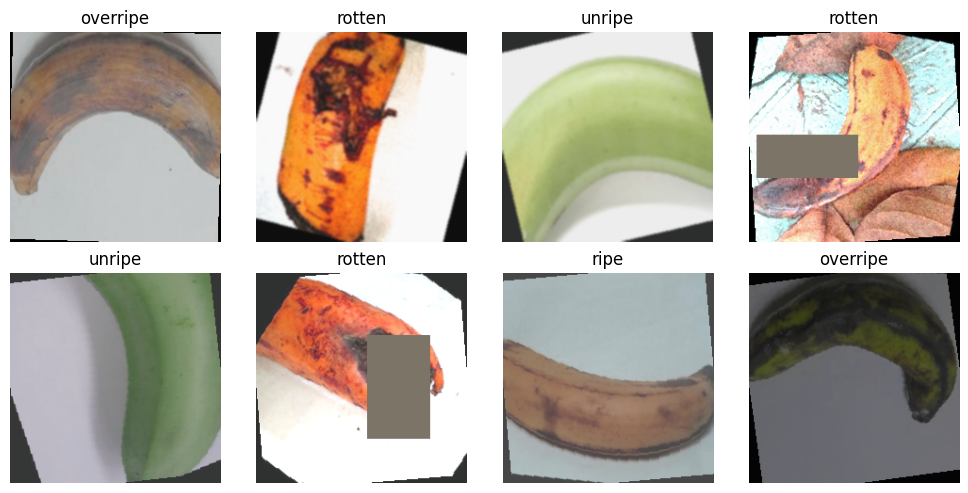

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

# Denormalize for display (undo Normalize so colours look correct)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].cpu() * std + mean          # denormalize
    img = img.permute(1, 2, 0).clamp(0, 1)      # HWC, clip to [0,1]
    ax.imshow(img.numpy())
    ax.set_title(train_dataset.classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Load pretrained MobileNetV2 model

In [ ]:
# MobileNetV2: lightweight, fast, great for deployment
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# MobileNetV2 classifier is a Sequential; replace only the final Linear
num_features = model.classifier[1].in_features  # 1280
model.classifier[1] = nn.Linear(num_features, 4)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 142MB/s]


### Loss function : Cross Entropy loss
### Optimizer     : Adam  (lr=0.0001)
### Scheduler     : ReduceLROnPlateau  — halves LR if val_loss stalls 2 epochs

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Reduce LR by ×0.5 if validation loss doesn't improve for 2 consecutive epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [ ]:
print(model)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

### Training function

In [ ]:
def train_model(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

### Validation function

In [ ]:
def validate_model(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Model Training

In [ ]:
num_epochs = 15
best_val_loss = float('inf')
best_epoch    = 0

for epoch in range(num_epochs):

    train_loss, train_acc = train_model(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_model(
        model, valid_loader, criterion, device
    )

    # Step scheduler based on validation loss
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Accuracy: {val_acc:.4f}")

    # Save best checkpoint (not necessarily the last epoch)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch + 1
        torch.save(model.state_dict(),
                   "/content/drive/MyDrive/banana_mobilenetv2_best.pth")
        print(f"  ✅ Best model saved (epoch {best_epoch}, val_loss={best_val_loss:.4f})")

    print("-" * 50)

print(f"\nTraining complete. Best epoch: {best_epoch} | Val Loss: {best_val_loss:.4f}")

Epoch [1/15]
Train Loss: 0.2399 | Train Accuracy: 0.9167
Val   Loss: 0.0785 | Val   Accuracy: 0.9768
  ✅ Best model saved (epoch 1, val_loss=0.0785)
--------------------------------------------------
Epoch [2/15]
Train Loss: 0.1313 | Train Accuracy: 0.9554
Val   Loss: 0.0769 | Val   Accuracy: 0.9795
  ✅ Best model saved (epoch 2, val_loss=0.0769)
--------------------------------------------------
Epoch [3/15]
Train Loss: 0.1072 | Train Accuracy: 0.9624
Val   Loss: 0.0609 | Val   Accuracy: 0.9804
  ✅ Best model saved (epoch 3, val_loss=0.0609)
--------------------------------------------------
Epoch [4/15]
Train Loss: 0.0882 | Train Accuracy: 0.9696
Val   Loss: 0.0625 | Val   Accuracy: 0.9777
--------------------------------------------------
Epoch [5/15]
Train Loss: 0.0758 | Train Accuracy: 0.9750
Val   Loss: 0.0604 | Val   Accuracy: 0.9813
  ✅ Best model saved (epoch 5, val_loss=0.0604)
--------------------------------------------------
Epoch [6/15]
Train Loss: 0.0639 | Train Accuracy

In [ ]:
import torch

# Also save the final (last) epoch weights separately
save_path = "/content/drive/MyDrive/banana_mobilenetv2_final.pth"
torch.save(model.state_dict(), save_path)
print("Final model saved to:", save_path)
print("Best  model saved to: /content/drive/MyDrive/banana_mobilenetv2_best.pth")

Final model saved to: /content/drive/MyDrive/banana_mobilenetv2_final.pth
Best  model saved to: /content/drive/MyDrive/banana_mobilenetv2_best.pth


## Test Metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print("Test Metrics\n")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix")
print(cm)

Test Metrics

Accuracy  : 0.9929
Precision : 0.9928
Recall    : 0.9934
F1 Score  : 0.9931

Confusion Matrix
[[113   0   0   0]
 [  0 153   1   0]
 [  0   0 183   2]
 [  0   0   1 109]]


Please upload one or more banana images to test:


Saving Screenshot 2026-04-11 151044.png to Screenshot 2026-04-11 151044.png


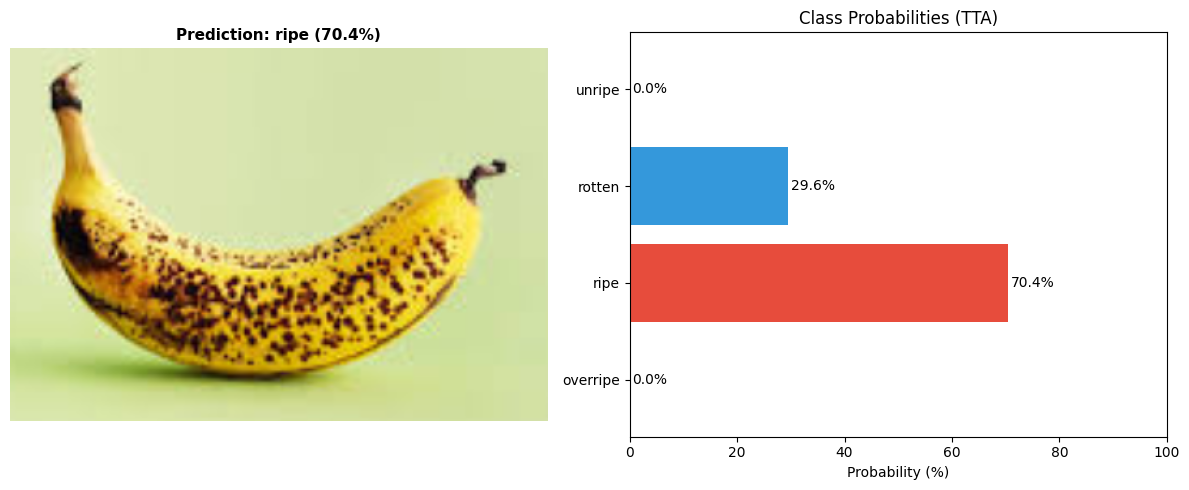

In [28]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
from google.colab import files

# ── Load best checkpoint for inference ───────────────────────────────────
model.load_state_dict(torch.load("/content/drive/MyDrive/banana_mobilenetv2_best.pth",
                                  map_location=device))
model.eval()

# ── Inference transform (same as validation, NO augmentation) ────────────
inference_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ── Label mapping ────────────────────────────────────────────────────────
idx_to_class = {0: 'overripe', 1: 'ripe', 2: 'rotten', 3: 'unripe'}

# ── Low-light / high-light auto-correction helper ────────────────────────
def auto_correct_exposure(pil_img):
    """
    Automatically normalize extreme brightness before inference.
    - Very dark images  (mean < 60)  → boost brightness
    - Very bright images(mean > 200) → reduce brightness
    Returns the corrected PIL image AND a tag string for the plot title.
    """
    import numpy as np
    arr  = np.array(pil_img.convert('L'))   # grayscale for brightness check
    mean = arr.mean()

    tag = ""
    if mean < 60:
        factor = min(2.5, 120.0 / (mean + 1e-6))  # brighten, cap at 2.5×
        pil_img = ImageEnhance.Brightness(pil_img).enhance(factor)
        tag = f" [low-light corrected, orig_mean={mean:.0f}]"
    elif mean > 200:
        factor = max(0.5, 160.0 / (mean + 1e-6))  # darken, floor at 0.5×
        pil_img = ImageEnhance.Brightness(pil_img).enhance(factor)
        tag = f" [high-light corrected, orig_mean={mean:.0f}]"

    return pil_img, tag

# ── Test-Time Augmentation (TTA): average 5 slightly varied predictions ──
tta_transforms = [
    # 1. Standard centre crop
    transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    # 2. Horizontal flip
    transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    # 3. Slightly smaller crop (different scale)
    transforms.Compose([
        transforms.Resize(280), transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    # 4. Slight rotation +10°
    transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(224),
        transforms.RandomRotation(degrees=(10, 10)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    # 5. Slight rotation −10°
    transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(224),
        transforms.RandomRotation(degrees=(-10, -10)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
]

def predict_with_tta(pil_img, model, device, tta_transforms):
    """Average softmax probabilities over all TTA variants."""
    all_probs = []
    with torch.no_grad():
        for tfm in tta_transforms:
            tensor = tfm(pil_img).unsqueeze(0).to(device)
            logits = model(tensor)
            probs  = F.softmax(logits, dim=1)
            all_probs.append(probs)
    avg_probs = torch.stack(all_probs).mean(dim=0)   # shape (1, 4)
    confidence, pred_idx = torch.max(avg_probs, dim=1)
    return pred_idx.item(), confidence.item(), avg_probs.squeeze().cpu().numpy()

# ── Confidence threshold: show warning if model is uncertain ─────────────
CONFIDENCE_THRESHOLD = 0.60

# ── Upload and predict ───────────────────────────────────────────────────
print("Please upload one or more banana images to test:")
uploaded = files.upload()

for file_name in uploaded.keys():
    raw_img = Image.open(file_name).convert('RGB')

    # Auto-correct exposure before inference
    corrected_img, exposure_tag = auto_correct_exposure(raw_img)

    # Predict with TTA on the corrected image
    pred_idx, confidence, all_probs = predict_with_tta(
        corrected_img, model, device, tta_transforms
    )

    predicted_label = idx_to_class[pred_idx]
    conf_pct        = confidence * 100

    # Build title with warnings
    warning = " ⚠️ LOW CONFIDENCE" if confidence < CONFIDENCE_THRESHOLD else ""
    title   = (f"Prediction: {predicted_label} ({conf_pct:.1f}%)"
               f"{warning}{exposure_tag}")

    # ── Plot original + per-class probability bar chart ──────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left: original (raw, un-corrected) image
    axes[0].imshow(raw_img)
    axes[0].set_title(title, fontsize=11, fontweight='bold', wrap=True)
    axes[0].axis('off')

    # Right: probability bar chart for all 4 classes
    class_names = [idx_to_class[i] for i in range(4)]
    bar_colors  = ['#e74c3c' if i == pred_idx else '#3498db' for i in range(4)]
    axes[1].barh(class_names, all_probs * 100, color=bar_colors)
    axes[1].set_xlabel('Probability (%)')
    axes[1].set_title('Class Probabilities (TTA)')
    axes[1].set_xlim(0, 100)
    for i, v in enumerate(all_probs * 100):
        axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    if confidence < CONFIDENCE_THRESHOLD:
        print(f"⚠️  '{file_name}': confidence only {conf_pct:.1f}% — "
              f"image may be unclear, obstructed, or not a banana.")
